<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Ejemplo_HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
import os
import zipfile
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

zip_path = "/content/har.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset descargado correctamente")

Dataset descargado correctamente


In [4]:
base_path = "/content/UCI HAR Dataset"

activity_labels = pd.read_csv(
    f"{base_path}/activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)

activity_labels

,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [5]:
X_train = pd.read_csv(
    f"{base_path}/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    f"{base_path}/train/y_train.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id"]
)

print("X:", X_train.shape)
print("Y:", y_train.shape)

X: (7352, 561)
Y: (7352, 1)


In [6]:
X = X_train.iloc[:, [0, 1, 2]].copy()

X.columns = [
    "sensor_x",
    "sensor_y",
    "sensor_z"
]

X.head()

,sensor_x,sensor_y,sensor_z
0,0.288585,-0.020294,-0.132905
1,0.278419,-0.016411,-0.123520
2,0.279653,-0.019467,-0.113462
3,0.279174,-0.026201,-0.123283
4,0.276629,-0.016570,-0.115362


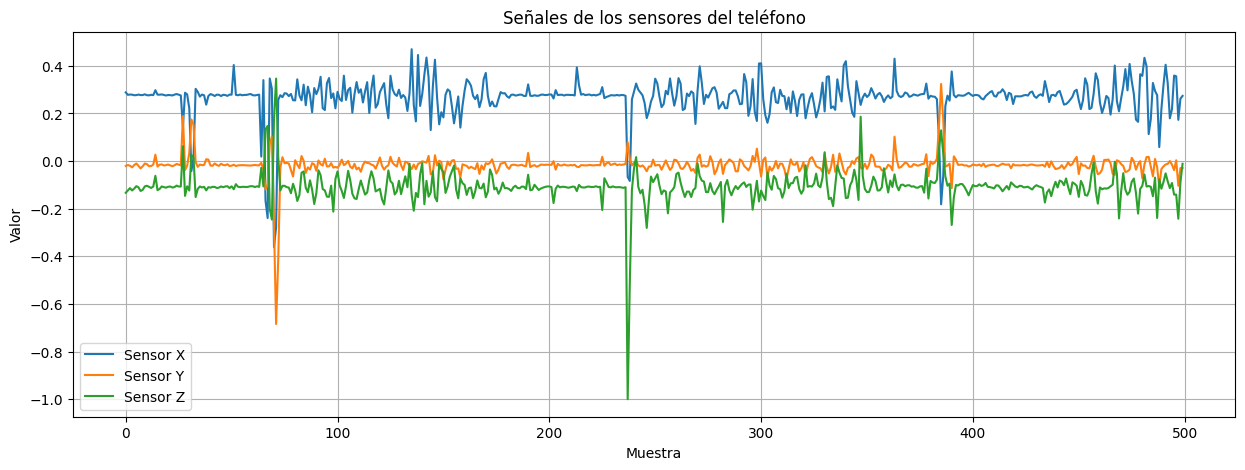

In [7]:
plt.figure(figsize=(15, 5))

plt.plot(X["sensor_x"].values[:500], label="Sensor X")
plt.plot(X["sensor_y"].values[:500], label="Sensor Y")
plt.plot(X["sensor_z"].values[:500], label="Sensor Z")

plt.title("Señales de los sensores del teléfono")
plt.xlabel("Muestra")
plt.ylabel("Valor")

plt.legend()
plt.grid()

plt.show()

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(7352, 3)

In [9]:
model = GaussianHMM(
    n_components=6,
    covariance_type="diag",
    n_iter=100,
    random_state=42
)

print(model)

GaussianHMM(n_components=6, n_iter=100, random_state=42)


In [10]:
model = GaussianHMM(
    n_components=6,
    covariance_type="diag",
    n_iter=100,
    random_state=42
)

print(model)

GaussianHMM(n_components=6, n_iter=100, random_state=42)


In [12]:
model.fit(X_scaled)
hidden_states = model.predict(X_scaled)

print(hidden_states[:50])

[0 0 0 0 0 0 0 0 0 0 0 3 3 3 5 0 0 3 3 3 3 3 3 3 3 3 3 2 1 3 2 2 2 1 0 0 3
 3 1 1 3 3 0 3 3 0 3 3 3 3]


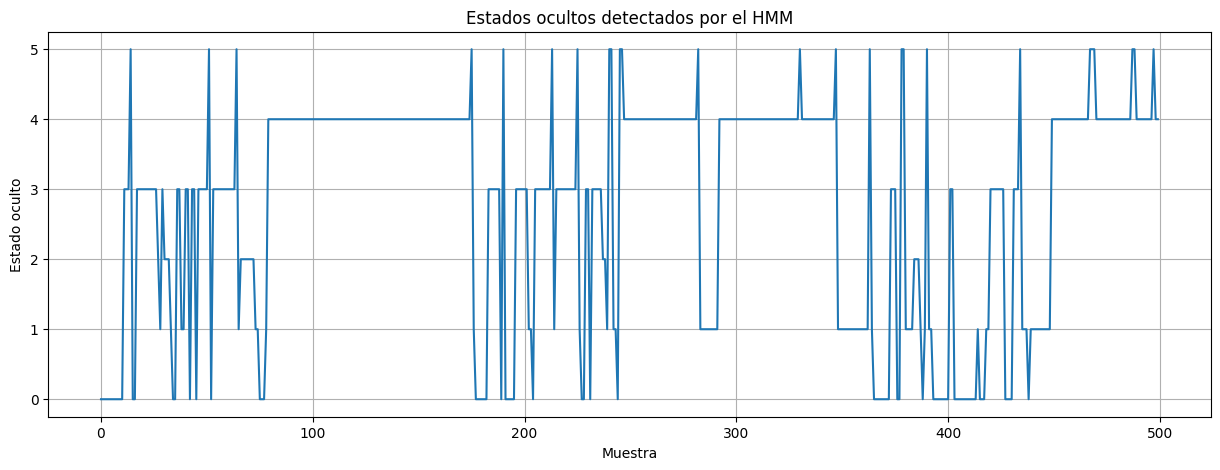

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(hidden_states[:500])

plt.title("Estados ocultos detectados por el HMM")

plt.xlabel("Muestra")
plt.ylabel("Estado oculto")

plt.grid()

plt.show()

In [14]:
transition_matrix = model.transmat_

transition_df = pd.DataFrame(
    transition_matrix,
    index=[f"Estado {i}" for i in range(6)],
    columns=[f"Estado {i}" for i in range(6)]
)

transition_df

,Estado 0,Estado 1,Estado 2,Estado 3,Estado 4,Estado 5
Estado 0,6.624176e-01,0.098077,6.918706e-03,1.881636e-01,7.213841e-14,0.044423
Estado 1,2.301953e-01,0.654964,8.325946e-03,3.286216e-02,3.335553e-02,0.040297
Estado 2,2.420236e-11,0.322501,5.768746e-01,3.530222e-82,4.840612e-60,0.100624
Estado 3,1.464683e-01,0.034426,1.405990e-02,7.534550e-01,2.296964e-15,0.051591
Estado 4,5.904709e-15,0.001182,2.587417e-55,1.271978e-25,8.939265e-01,0.104892
Estado 5,3.575443e-02,0.277170,9.011241e-09,3.471048e-52,2.629020e-01,0.424174


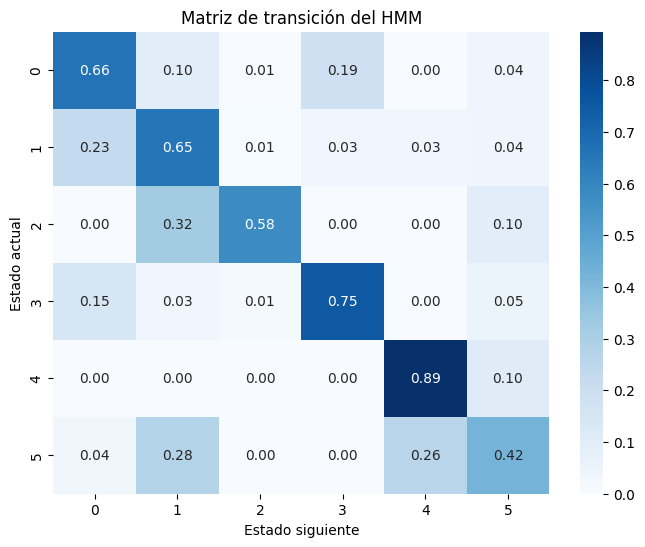

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    transition_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Matriz de transición del HMM")

plt.xlabel("Estado siguiente")
plt.ylabel("Estado actual")

plt.show()

In [16]:
print("Medias de los estados:")
print(model.means_)

Medias de los estados:
[[ 0.0408319   0.02247073  0.00996123]
 [ 0.01546162 -0.0129036   0.0079125 ]
 [-2.12297715  1.1953856   1.0679345 ]
 [ 0.04317152  0.01923304  0.01545407]
 [ 0.08232555 -0.00973444  0.00852049]
 [-0.16654939 -0.17802739 -0.21983926]]


In [17]:
means = pd.DataFrame(
    model.means_,
    columns=["Sensor X", "Sensor Y", "Sensor Z"]
)

means

,Sensor X,Sensor Y,Sensor Z
0,0.040832,0.022471,0.009961
1,0.015462,-0.012904,0.007912
2,-2.122977,1.195386,1.067934
3,0.043172,0.019233,0.015454
4,0.082326,-0.009734,0.008520
5,-0.166549,-0.178027,-0.219839


<Figure size 1000x500 with 0 Axes>

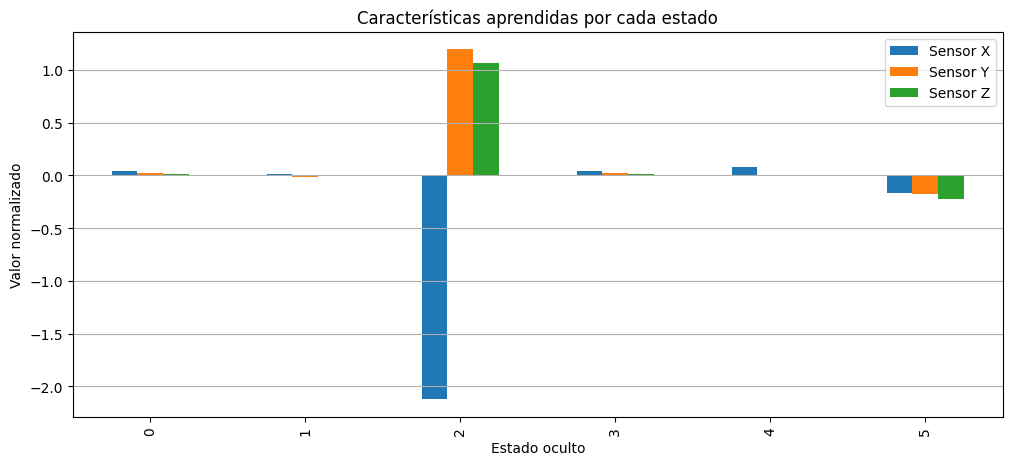

In [18]:
plt.figure(figsize=(10, 5))

means.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Características aprendidas por cada estado")
plt.xlabel("Estado oculto")
plt.ylabel("Valor normalizado")

plt.grid(axis="y")

plt.show()

In [19]:
real_labels = y_train["activity_id"].values

comparison = pd.DataFrame({
    "Actividad_real": real_labels,
    "Estado_HMM": hidden_states
})

comparison.head(20)

,Actividad_real,Estado_HMM
0,5,0
1,5,0
2,5,0
3,5,0
4,5,0
5,5,0
6,5,0
7,5,0
8,5,0
9,5,0


In [20]:
activity_dict = dict(
    zip(
        activity_labels["id"],
        activity_labels["activity"]
    )
)

comparison["Actividad_real_nombre"] = comparison[
    "Actividad_real"
].map(activity_dict)

comparison.head(20)

,Actividad_real,Estado_HMM,Actividad_real_nombre
0,5,0,STANDING
1,5,0,STANDING
2,5,0,STANDING
3,5,0,STANDING
4,5,0,STANDING
5,5,0,STANDING
6,5,0,STANDING
7,5,0,STANDING
8,5,0,STANDING
9,5,0,STANDING


In [21]:
for estado in sorted(comparison["Estado_HMM"].unique()):

    subset = comparison[
        comparison["Estado_HMM"] == estado
    ]

    print("\n==========================")
    print("ESTADO HMM:", estado)
    print("==========================")

    print(
        subset["Actividad_real_nombre"]
        .value_counts()
        .head()
    )


ESTADO HMM: 0
Actividad_real_nombre
STANDING            673
LAYING              453
SITTING             442
WALKING              15
WALKING_UPSTAIRS      3
Name: count, dtype: int64

ESTADO HMM: 1
Actividad_real_nombre
LAYING              332
WALKING             273
STANDING            260
SITTING             205
WALKING_UPSTAIRS    115
Name: count, dtype: int64

ESTADO HMM: 2
Actividad_real_nombre
LAYING      63
SITTING     27
STANDING     5
Name: count, dtype: int64

ESTADO HMM: 3
Actividad_real_nombre
SITTING     539
LAYING      472
STANDING    354
Name: count, dtype: int64

ESTADO HMM: 4
Actividad_real_nombre
WALKING               905
WALKING_DOWNSTAIRS    893
WALKING_UPSTAIRS      739
STANDING                9
LAYING                  6
Name: count, dtype: int64

ESTADO HMM: 5
Actividad_real_nombre
WALKING_UPSTAIRS      216
WALKING_DOWNSTAIRS     82
LAYING                 81
STANDING               73
SITTING                73
Name: count, dtype: int64


In [22]:
mapping = {}

for estado in range(6):

    subset = comparison[
        comparison["Estado_HMM"] == estado
    ]

    if len(subset) > 0:

        actividad = (
            subset["Actividad_real_nombre"]
            .value_counts()
            .idxmax()
        )

        mapping[estado] = actividad

mapping

{0: 'STANDING',
 1: 'LAYING',
 2: 'LAYING',
 3: 'SITTING',
 4: 'WALKING',
 5: 'WALKING_UPSTAIRS'}

In [23]:
predicted_activity = [
    mapping.get(state, "DESCONOCIDO")
    for state in hidden_states
]

comparison["Prediccion"] = predicted_activity

comparison.head(20)

,Actividad_real,Estado_HMM,Actividad_real_nombre,Prediccion
0,5,0,STANDING,STANDING
1,5,0,STANDING,STANDING
2,5,0,STANDING,STANDING
3,5,0,STANDING,STANDING
4,5,0,STANDING,STANDING
5,5,0,STANDING,STANDING
6,5,0,STANDING,STANDING
7,5,0,STANDING,STANDING
8,5,0,STANDING,STANDING
9,5,0,STANDING,STANDING


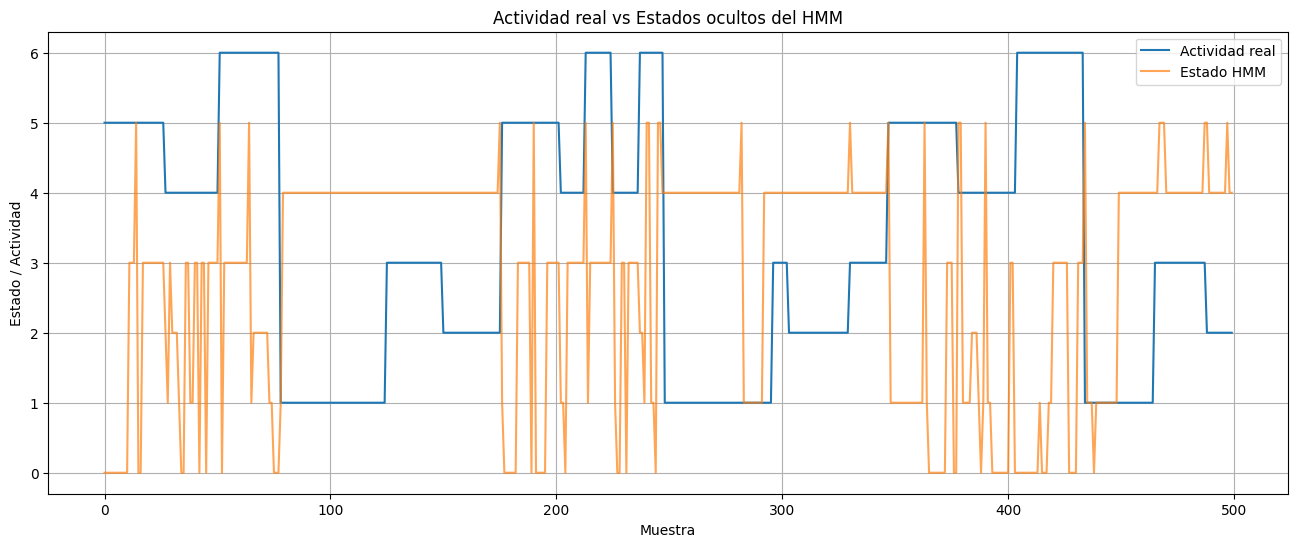

In [24]:
plt.figure(figsize=(16, 6))

plt.plot(
    comparison["Actividad_real"].values[:500],
    label="Actividad real"
)

plt.plot(
    comparison["Estado_HMM"].values[:500],
    label="Estado HMM",
    alpha=0.7
)

plt.title("Actividad real vs Estados ocultos del HMM")

plt.xlabel("Muestra")
plt.ylabel("Estado / Actividad")

plt.legend()

plt.grid()

plt.show()

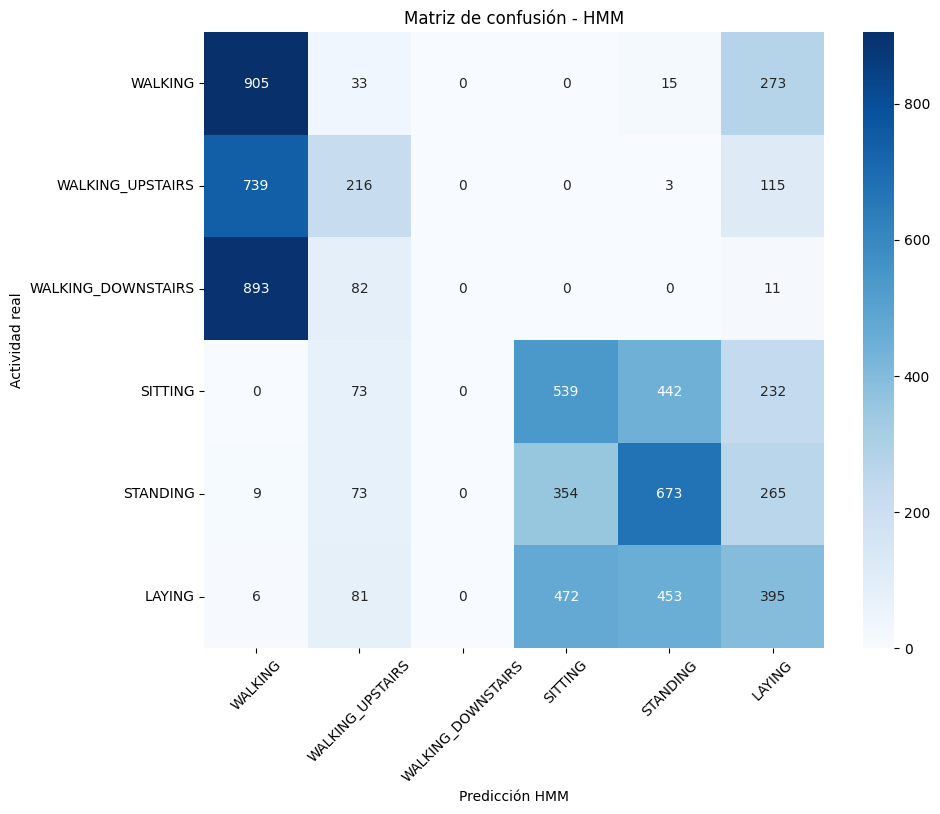

In [25]:
from sklearn.metrics import confusion_matrix

# Convertir actividades reales a nombres
real_names = comparison["Actividad_real_nombre"]

# Convertir estados HMM a actividades
pred_names = comparison["Prediccion"]

labels = activity_labels["activity"].tolist()

cm = confusion_matrix(
    real_names,
    pred_names,
    labels=labels
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.title("Matriz de confusión - HMM")

plt.xlabel("Predicción HMM")

plt.ylabel("Actividad real")

plt.xticks(rotation=45)

plt.show()

In [26]:
import numpy as np
from hmmlearn import hmm

# Estados ocultos
# 0 = Soleado
# 1 = Lluvioso

model = hmm.CategoricalHMM(
    n_components=2,
    n_iter=100,
    random_state=42
)

# Probabilidad inicial
model.startprob_ = np.array([
    0.6,
    0.4
])

# Probabilidad de transición
model.transmat_ = np.array([
    [0.8, 0.2],
    [0.3, 0.7]
])

# Observaciones
# 0 = caminar
# 1 = comprar
# 2 = paraguas

model.emissionprob_ = np.array([
    [0.6, 0.3, 0.1],
    [0.1, 0.2, 0.7]
])

# Observaciones
observaciones = np.array([
    [0],
    [0],
    [1],
    [2],
    [2],
    [2]
])

# Encontrar estados ocultos
estados = model.predict(observaciones)

print("Observaciones:")
print(observaciones.flatten())

print("\nEstados ocultos:")
print(estados)

Observaciones:
[0 0 1 2 2 2]

Estados ocultos:
[0 0 0 1 1 1]
